# Klasifikasi Kelayakan Kapal Penangkap Ikan Menggunakan Histogram of Oriented Gradients (HOG) dan Support Vector Machine (SVM)

Notebook ini digunakan untuk mengklasifikasikan kondisi lambung kapal (Baik / Rusak) menggunakan HOG dan SVM.


## 1. Import Library


In [28]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from skimage.feature import hog
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Set seed for reproducibility
np.random.seed(42)


## 2. Load Dataset

Dataset disimpan di dalam folder `dataset/` yang berisi subfolder `baik/` dan `rusak/`.


In [29]:
DATASET_PATH = 'dataset'
CATEGORIES = ['baik', 'rusak']

def load_data(dataset_path, categories):
    image_paths = []
    labels = []
    
    for category in categories:
        folder_path = os.path.join(dataset_path, category)
        label = 1 if category == 'baik' else 0 # 1 untuk Baik, 0 untuk Rusak
        
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} tidak ditemukan.")
            continue
            
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(folder_path, filename)
                image_paths.append(img_path)
                labels.append(label)
                
    return image_paths, labels

image_paths, labels = load_data(DATASET_PATH, CATEGORIES)
print(f"Total gambar ditemukan: {len(image_paths)}")
print(f"Total label: {len(labels)}")


Total gambar ditemukan: 11
Total label: 11


## 3. Preprocessing

Tahapan preprocessing:
1. Read Image
2. Resize image menjadi 128x128
3. Convert ke grayscale
4. Normalisasi pixel (dilakukan bersamaan dengan pembacaan gambar atau scaling nantinya)


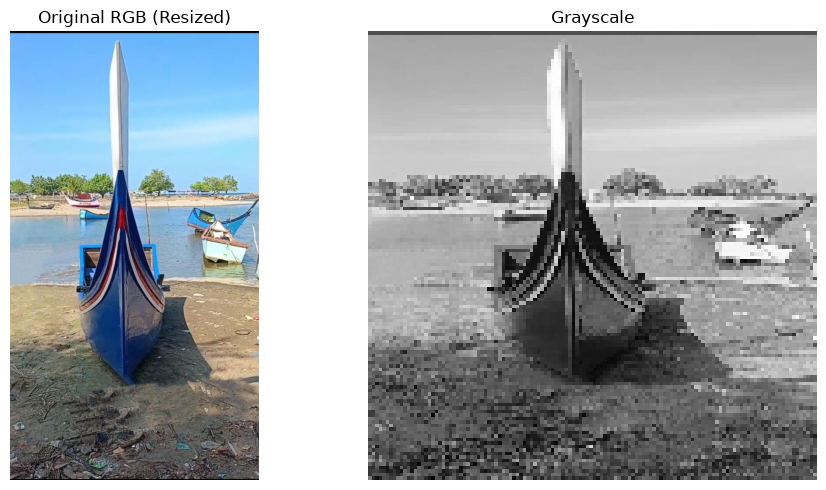

In [30]:
IMG_SIZE = (128, 128)

def preprocess_image(img_path):
    # 1. Read Image
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")
        
    # Convert BGR to RGB untuk visualisasi
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. Resize Image
    img_resized = cv2.resize(img_rgb, IMG_SIZE)
    
    # 3. Convert ke Grayscale
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    
    return img_rgb, img_gray

# Visualisasi contoh preprocessing
if len(image_paths) > 0:
    sample_path = image_paths[0]
    img_rgb, img_gray = preprocess_image(sample_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original RGB (Resized)")
    axes[0].axis('off')
    
    axes[1].imshow(img_gray, cmap='gray')
    axes[1].set_title("Grayscale")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


## 4. HOG Feature Extraction

Parameter yang digunakan:
- orientations = 9
- pixels_per_cell = (8, 8)
- cells_per_block = (2, 2)
- block_norm = 'L2-Hys'


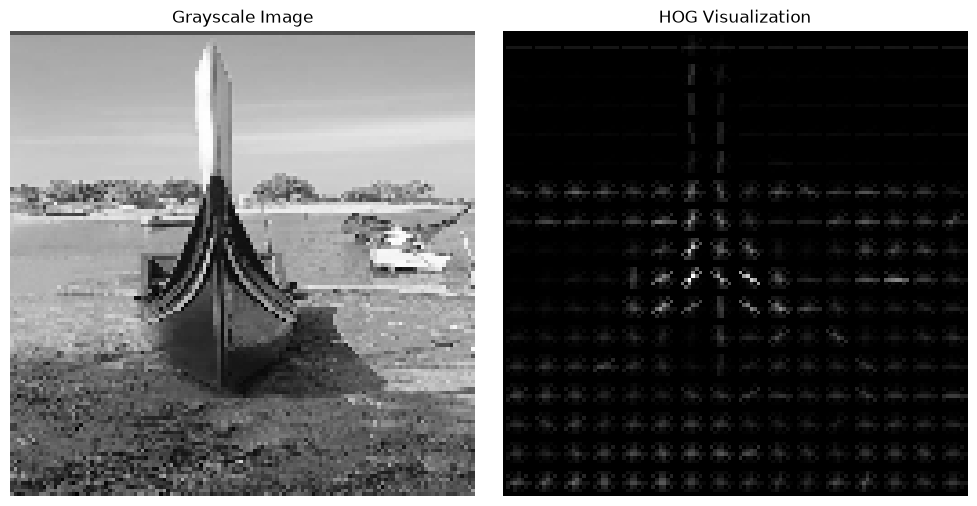

Dimensi fitur HOG: (8100,)


In [31]:
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM = 'L2-Hys'

def extract_hog_features(img_gray, visualize=False):
    if visualize:
        features, hog_image = hog(
            img_gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm=HOG_BLOCK_NORM,
            visualize=True,
            transform_sqrt=True
        )
        return features, hog_image
    else:
        features = hog(
            img_gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm=HOG_BLOCK_NORM,
            visualize=False,
            transform_sqrt=True
        )
        return features

# Visualisasi HOG pada contoh gambar
if len(image_paths) > 0:
    features, hog_image = extract_hog_features(img_gray, visualize=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title("Grayscale Image")
    axes[0].axis('off')
    
    axes[1].imshow(hog_image, cmap='gray')
    axes[1].set_title("HOG Visualization")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Dimensi fitur HOG: {features.shape}")


## 5. Dataset Preparation

Mengekstraksi fitur HOG untuk seluruh data dan membentuk DataFrame.


In [32]:
X = []
y = []

print("Mengekstraksi fitur HOG...")
for path, label in zip(image_paths, labels):
    try:
        _, img_gray = preprocess_image(path)
        features = extract_hog_features(img_gray)
        X.append(features)
        y.append(label)
    except Exception as e:
        print(f"Error memproses {path}: {e}")

X = np.array(X)
y = np.array(y)

# Membentuk DataFrame
if len(X) > 0:
    feature_cols = [f'hog_{i}' for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_cols)
    df['label'] = y
    
    print(f"Total data berhasil diproses: {len(df)}")
    print("\nDistribusi Kelas (1: Baik, 0: Rusak):")
    print(df['label'].value_counts())
    
    print("\nPreview DataFrame:")
    display(df.head())
else:
    print("Dataset kosong. Pastikan gambar ada di folder dataset.")


Mengekstraksi fitur HOG...
Total data berhasil diproses: 11

Distribusi Kelas (1: Baik, 0: Rusak):
label
1    7
0    4
Name: count, dtype: int64

Preview DataFrame:


,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,hog_8091,hog_8092,hog_8093,hog_8094,hog_8095,hog_8096,hog_8097,hog_8098,hog_8099,label
0,0.008161,0.000000,0.000000,0.012181,0.676199,0.066903,0.015458,0.006094,0.000000,0.002720,...,0.223464,0.169220,0.111746,0.115525,0.229600,0.126788,0.122520,0.073762,0.229600,1
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
2,0.200743,0.000000,0.015656,0.000000,0.222881,0.249513,0.284800,0.164662,0.070258,0.033653,...,0.246005,0.136579,0.100554,0.169963,0.246005,0.183281,0.233097,0.188299,0.065189,1
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.078832,0.000000,0.133648,0.035300,0.356800,0.000000,0.022238,0.000000,0.000000,1
4,0.206756,0.217098,0.148653,0.186610,0.196374,0.142166,0.111596,0.024534,0.004560,0.217098,...,0.077981,0.017035,0.117309,0.145866,0.260527,0.183377,0.095225,0.119772,0.146564,1


## 6. Train Test Split

Pembagian data menggunakan rasio:
- 80% Training
- 20% Testing
- random_state = 42
- stratify = y


In [33]:
if len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.20, 
        random_state=42, 
        stratify=y
    )
    
    print(f"Jumlah data training: {len(X_train)}")
    print(f"Jumlah data testing: {len(X_test)}")


Jumlah data training: 8
Jumlah data testing: 3


## 7. Feature Scaling

Normalisasi fitur menggunakan StandardScaler dan menyimpan scaler-nya.


In [34]:
if len(X) > 0:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Buat direktori models jika belum ada
    os.makedirs('models', exist_ok=True)
    
    # Simpan scaler
    scaler_path = 'models/scaler.pkl'
    joblib.dump(scaler, scaler_path)
    print(f"Scaler berhasil disimpan di: {scaler_path}")


Scaler berhasil disimpan di: models/scaler.pkl


## 8. SVM Linear Training

Melatih model SVM dengan kernel Linear dan GridSearchCV.


In [35]:
if len(X) > 0:
    print("Melatih SVM Linear...")
    param_grid_linear = {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear']
    }
    
    svm_linear = SVC(probability=True, random_state=42)
    grid_linear = GridSearchCV(
        svm_linear, 
        param_grid_linear, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1,
        verbose=1
    )
    
    grid_linear.fit(X_train_scaled, y_train)
    
    best_linear_model = grid_linear.best_estimator_
    print(f"Best parameter Linear: {grid_linear.best_params_}")


Melatih SVM Linear...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


d:\Programming\seaworthiness\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameter Linear: {'C': 0.1, 'kernel': 'linear'}


d:\Programming\seaworthiness\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 9. SVM RBF Training

Melatih model SVM dengan kernel RBF dan GridSearchCV.


In [36]:
if len(X) > 0:
    print("Melatih SVM RBF...")
    param_grid_rbf = {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1],
        'kernel': ['rbf']
    }
    
    svm_rbf = SVC(probability=True, random_state=42)
    grid_rbf = GridSearchCV(
        svm_rbf, 
        param_grid_rbf, 
        cv=5, 
        scoring='accuracy', 
        n_jobs=-1,
        verbose=1
    )
    
    grid_rbf.fit(X_train_scaled, y_train)
    
    best_rbf_model = grid_rbf.best_estimator_
    print(f"Best parameter RBF: {grid_rbf.best_params_}")


d:\Programming\seaworthiness\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Melatih SVM RBF...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameter RBF: {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}


d:\Programming\seaworthiness\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 10. Evaluation

Evaluasi performa kedua model pada data testing.


In [37]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print(f"--- Evaluasi {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}\n")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Rusak (0)', 'Baik (1)'], zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    
    return acc, prec, rec, f1, cm

if len(X) > 0:
    acc_lin, prec_lin, rec_lin, f1_lin, cm_lin = evaluate_model(best_linear_model, X_test_scaled, y_test, "SVM Linear")
    acc_rbf, prec_rbf, rec_rbf, f1_rbf, cm_rbf = evaluate_model(best_rbf_model, X_test_scaled, y_test, "SVM RBF")


--- Evaluasi SVM Linear ---
Accuracy : 0.6667
Precision: 0.6667
Recall   : 1.0000
F1 Score : 0.8000

Classification Report:
              precision    recall  f1-score   support

   Rusak (0)       0.00      0.00      0.00         1
    Baik (1)       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

--- Evaluasi SVM RBF ---
Accuracy : 0.6667
Precision: 0.6667
Recall   : 1.0000
F1 Score : 0.8000

Classification Report:
              precision    recall  f1-score   support

   Rusak (0)       0.00      0.00      0.00         1
    Baik (1)       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



## 11. Model Comparison & Visualization

Membuat visualisasi perbandingan model dan Confusion Matrix.


C:\Users\Husein\AppData\Local\Temp\ipykernel_2460\936518822.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


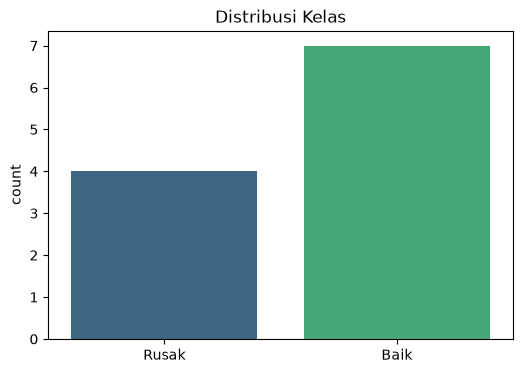

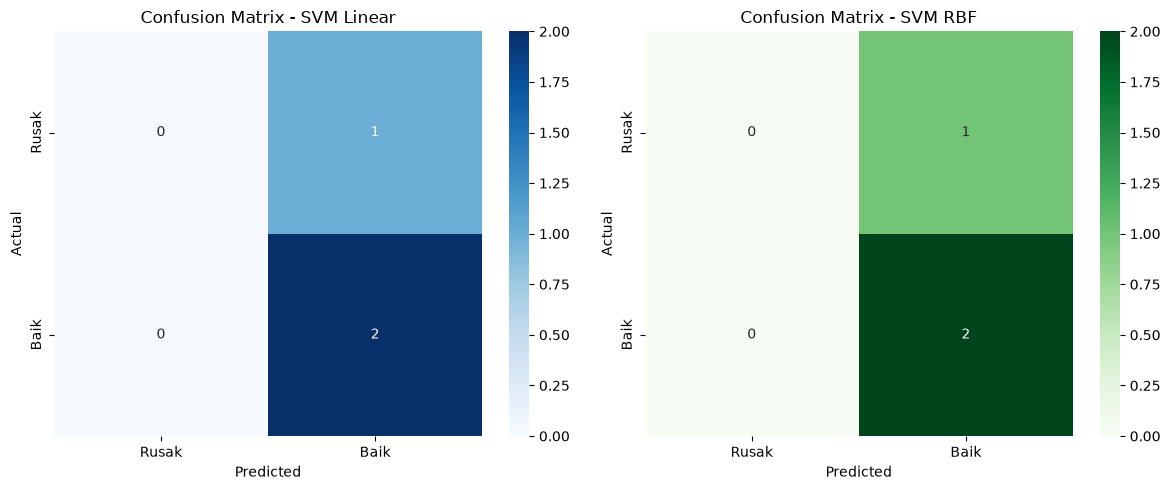

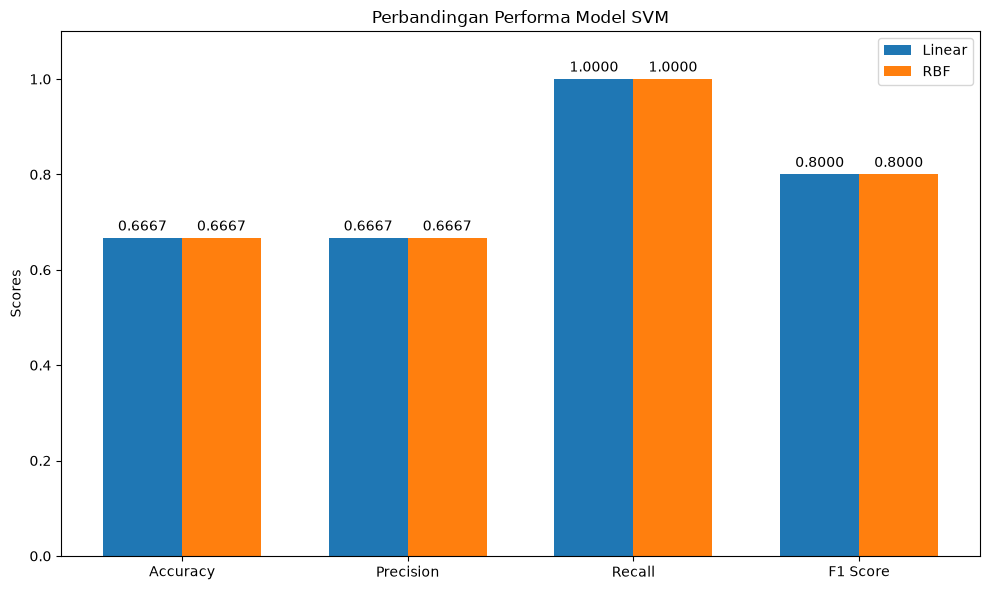

In [38]:
if len(X) > 0:
    # 1. Distribusi Kelas
    plt.figure(figsize=(6,4))
    sns.countplot(x=y, palette='viridis')
    plt.title("Distribusi Kelas")
    plt.xticks(ticks=[0, 1], labels=['Rusak', 'Baik'])
    plt.show()

    # 2 & 3. Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=['Rusak', 'Baik'], yticklabels=['Rusak', 'Baik'])
    axes[0].set_title('Confusion Matrix - SVM Linear')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=['Rusak', 'Baik'], yticklabels=['Rusak', 'Baik'])
    axes[1].set_title('Confusion Matrix - SVM RBF')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

    # 4-7. Perbandingan Metrik
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    linear_scores = [acc_lin, prec_lin, rec_lin, f1_lin]
    rbf_scores = [acc_rbf, prec_rbf, rec_rbf, f1_rbf]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, linear_scores, width, label='Linear')
    rects2 = ax.bar(x + width/2, rbf_scores, width, label='RBF')

    ax.set_ylabel('Scores')
    ax.set_title('Perbandingan Performa Model SVM')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0, 1.1)

    # Tambah nilai di atas bar
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


## 12. Save Best Model

Menyimpan model dengan akurasi tertinggi.


In [39]:
if len(X) > 0:
    best_model = best_linear_model if acc_lin >= acc_rbf else best_rbf_model
    best_model_name = "SVM Linear" if acc_lin >= acc_rbf else "SVM RBF"
    best_acc = max(acc_lin, acc_rbf)
    
    print(f"Model terbaik adalah {best_model_name} dengan accuracy {best_acc*100:.2f}%")
    
    model_path = 'models/svm_model.pkl'
    joblib.dump(best_model, model_path)
    print(f"Model terbaik berhasil disimpan di: {model_path}")


Model terbaik adalah SVM Linear dengan accuracy 66.67%
Model terbaik berhasil disimpan di: models/svm_model.pkl


## 13. Single Image Prediction

Melakukan prediksi pada gambar baru menggunakan model yang telah dilatih.


Contoh prediksi pada gambar dari dataset:


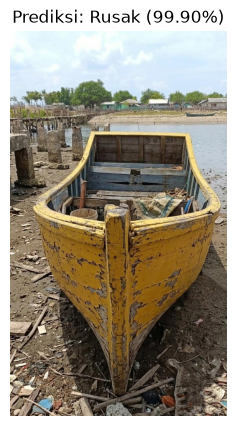

In [40]:
def predict_single_image(img_path, model, scaler):
    try:
        # Preprocessing & HOG
        img_rgb, img_gray = preprocess_image(img_path)
        features = extract_hog_features(img_gray)
        
        # Scaling
        features_scaled = scaler.transform([features])
        
        # Predict
        pred_label = model.predict(features_scaled)[0]
        prob = model.predict_proba(features_scaled)[0]
        
        # Mapping label
        label_text = 'Baik' if pred_label == 1 else 'Rusak'
        confidence = prob[pred_label] * 100
        
        # Visualisasi
        plt.figure(figsize=(5,5))
        plt.imshow(img_rgb)
        plt.title(f"Prediksi: {label_text} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()
        
        return label_text, prob
    except Exception as e:
        print(f"Error saat memprediksi: {e}")
        return None, None

if len(X) > 0 and len(image_paths) > 0:
    print("Contoh prediksi pada gambar dari dataset:")
    sample_test_image = image_paths[-1] # Ambil gambar terakhir
    predict_single_image(sample_test_image, best_model, scaler)


## 14. Conclusion

Berdasarkan hasil evaluasi, model berhasil dilatih untuk mengklasifikasikan kondisi lambung kapal (Baik / Rusak). Model terbaik disimpan dalam format `.pkl` yang dapat langsung diintegrasikan dengan aplikasi Flask.
